# Automotive Part Image-Text Matching — Dataset V3

## Deep Learning Final Exam Development Report

This project compares an automotive-part image with a short text description and predicts one of three relation labels:

- **MATCH** — image and text describe the same part;
- **PARTIAL_MATCH** — they describe different parts from the same broad vehicle subsystem;
- **MISMATCH** — they describe parts from different subsystems.

**Research question:** Can a compact neural model that combines image and text information outperform image-only, text-only, and simple multimodal baselines on independently grouped validation images?

This executed notebook reads saved train and validation artifacts only. The locked test split is not opened or evaluated.

## 1. Problem and motivation

Automotive catalogues and warehouses depend on a product photograph and its written description agreeing. A wrong pairing can create listing errors, incorrect picking, or avoidable returns.

The relation cannot be solved from one modality alone in this dataset design. Each image is paired with two examples from every relation label. The experiment therefore asks whether a model can use the interaction between visual and textual information rather than memorize a single category or source shortcut.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

ROOT = Path.cwd()
MANIFESTS = ROOT / "data" / "manifests" / "dataset_v3"
RESULTS = ROOT / "results" / "dataset_v3"

train_images = pd.read_csv(MANIFESTS / "dataset_v3_train_images.csv")
validation_images = pd.read_csv(MANIFESTS / "dataset_v3_validation_images.csv")
train_relations = pd.read_csv(MANIFESTS / "dataset_v3_train_relations.csv")
validation_relations = pd.read_csv(MANIFESTS / "dataset_v3_validation_relations.csv")
model_comparison = pd.read_csv(RESULTS / "model_comparison.csv")
all_predictions = pd.read_csv(RESULTS / "validation_predictions.csv")
main_predictions = pd.read_csv(RESULTS / "multimodal_validation_predictions.csv")
per_category = pd.read_csv(RESULTS / "multimodal_per_category.csv")
paired = pd.read_csv(RESULTS / "paired_comparisons.csv")
audit = json.loads((MANIFESTS / "dataset_v3_development_audit.json").read_text(encoding="utf-8"))
relation_summary = json.loads((MANIFESTS / "dataset_v3_relation_summary.json").read_text(encoding="utf-8"))
run_info = json.loads((RESULTS / "run_info.json").read_text(encoding="utf-8"))
training_summary = json.loads((RESULTS / "training_summary.json").read_text(encoding="utf-8"))
verification = json.loads((RESULTS / "verification_summary.json").read_text(encoding="utf-8"))

print(f"Dataset version: {run_info['dataset_version']}")
print(f"Python: {run_info['python_version']} | PyTorch: {run_info['torch_version']}")
print(f"Saved models: {run_info['saved_model_count']}")
print(f"Artifact verification: {verification['status']}")

Dataset version: 3.0-development
Python: 3.13.13 | PyTorch: 2.10.0+cpu
Saved models: 7
Artifact verification: PASS_DATASET_V3_DEVELOPMENT_TRAINING_VERIFIED


## 2. Data source and split

Dataset V3 uses a manually reviewed subset of the public **Car Parts 40 Classes** Kaggle dataset (`gpiosenka/car-parts-40-classes`), distributed under Apache-2.0 according to the source metadata recorded in the project.

The final pool contains 640 curated images in eight categories: alternator, brake disc, brake pad, coil spring, headlight, oil filter, starter, and taillight. The original source split labels were ignored. Images were re-split deterministically by SHA-256 ranking within each category:

- 480 train images — 60 per category;
- 80 validation images — 10 per category;
- 80 locked test images — 10 per category.

The project uses curated image-level group IDs. Exact hashes, perceptual review pairs, cross-category checks, and overlap with the earlier project image pool were zero before the split. This supports image-level separation, but it is not a claim that every public photograph represents a known unique physical object.

In [2]:
image_summary = pd.DataFrame({
    "split": ["train", "validation"],
    "independent_images": [len(train_images), len(validation_images)],
    "relation_rows": [len(train_relations), len(validation_relations)],
    "images_per_category": [
        train_images.groupby("project_category").size().iloc[0],
        validation_images.groupby("project_category").size().iloc[0],
    ],
    "unique_descriptions": [
        train_relations.description.nunique(),
        validation_relations.description.nunique(),
    ],
})
category_counts = pd.concat([
    train_images.groupby("project_category").size().rename("train"),
    validation_images.groupby("project_category").size().rename("validation"),
], axis=1)

display(image_summary)
display(category_counts)

,split,independent_images,relation_rows,images_per_category,unique_descriptions
0,train,480,2880,60,32
1,validation,80,480,10,16


,train,validation
project_category,,
alternator,60,10
brake_disc,60,10
brake_pad,60,10
coil_spring,60,10
headlight,60,10
oil_filter,60,10
starter,60,10
taillight,60,10


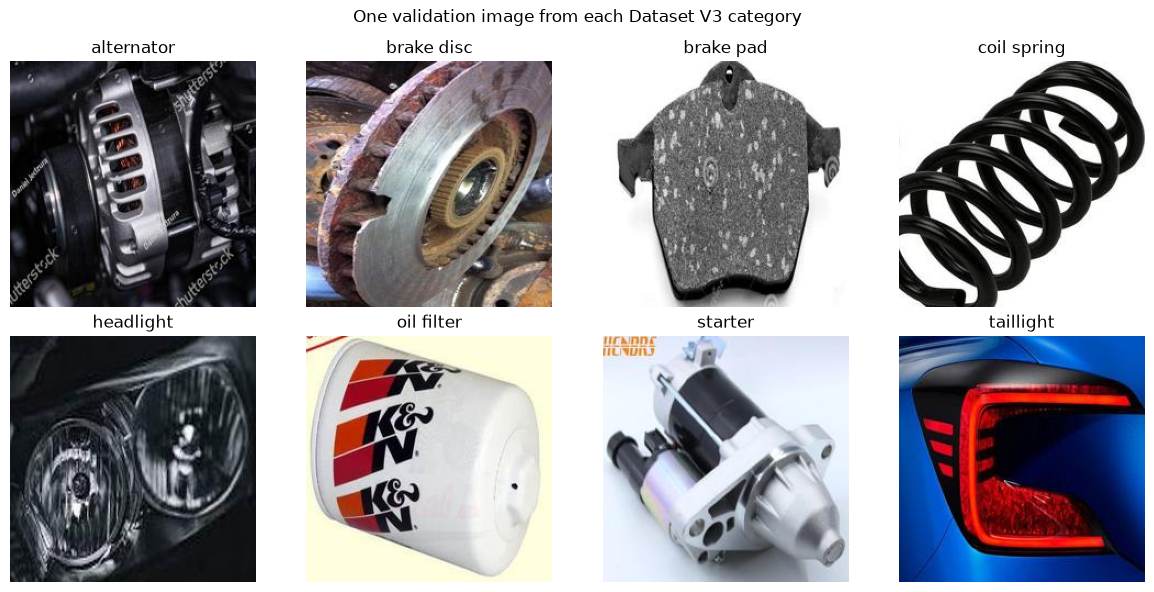

In [3]:
samples = (
    validation_images.sort_values(["project_category", "split_rank_within_category"])
    .groupby("project_category", as_index=False)
    .head(1)
)
available = samples.loc[samples["repository_relative_path"].map(lambda value: (ROOT / value).is_file())]

if len(available) == 8:
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for axis, row in zip(axes.ravel(), available.itertuples(index=False)):
        axis.imshow(plt.imread(ROOT / row.repository_relative_path))
        axis.set_title(row.project_category.replace("_", " "))
        axis.axis("off")
    fig.suptitle("One validation image from each Dataset V3 category")
    plt.tight_layout()
    plt.show()
else:
    print("Image binaries are not available in this execution environment; the manifest and result analysis continues.")

## 3. Relation construction

Each train or validation image creates six rows: two `MATCH`, two `PARTIAL_MATCH`, and two `MISMATCH` examples.

`PARTIAL_MATCH` has a precise rule: the image and text name different parts from the same broad subsystem:

- engine support and electrical: alternator, starter, oil filter;
- chassis: brake disc, brake pad, coil spring;
- lighting: headlight, taillight.

Train and validation use separate caption templates. There are no exact repeated descriptions across these splits. Text category is balanced across all three labels, so knowing only the named text category gives chance-level relation accuracy.

In [4]:
label_table = pd.concat([
    train_relations.label.value_counts().rename("train"),
    validation_relations.label.value_counts().rename("validation"),
], axis=1).loc[["MATCH", "PARTIAL_MATCH", "MISMATCH"]]

display(label_table)
display(
    validation_relations[[
        "part_category", "text_category", "description", "label"
    ]].head(9)
)

assert train_relations.groupby("image_id").size().eq(6).all()
assert validation_relations.groupby("image_id").size().eq(6).all()

,train,validation
label,,
MATCH,960,160
PARTIAL_MATCH,960,160
MISMATCH,960,160


,part_category,text_category,description,label
0,alternator,alternator,The pictured part is the automotive alternator...,MATCH
1,alternator,starter,The pictured part is the automotive starter mo...,PARTIAL_MATCH
2,alternator,brake_pad,The pictured part is the automotive brake pad;...,MISMATCH
3,alternator,alternator,This engine-support and electrical group compo...,MATCH
4,alternator,starter,This engine-support and electrical group compo...,PARTIAL_MATCH
5,alternator,coil_spring,This vehicle chassis group component is a susp...,MISMATCH
6,alternator,alternator,This engine-support and electrical group compo...,MATCH
7,alternator,starter,This engine-support and electrical group compo...,PARTIAL_MATCH
8,alternator,headlight,This vehicle lighting group component is a fro...,MISMATCH


## 4. Leakage, shortcuts, and statistical unit

The development audit checks group IDs, image IDs, paths, exact image hashes, and exact captions across train and validation. All measured overlaps are zero.

The six rows generated from one image are dependent. Therefore, 480 validation rows do not represent 480 independent visual examples. The independent validation unit is the set of 80 curated image groups. Confidence intervals resample whole image groups, and paired model comparisons use an image-group sign-flip procedure.

In [5]:
leakage = pd.Series({
    "part_group_overlap": audit["overlap"]["part_group_overlap"],
    "object_group_overlap": audit["overlap"]["object_group_overlap"],
    "image_id_overlap": audit["overlap"]["image_id_overlap"],
    "image_path_overlap": audit["overlap"]["image_path_overlap"],
    "exact_image_hash_overlap": audit["exact_cross_split_image_hash_overlap"],
    "exact_description_overlap": audit["exact_description_overlap"],
    "near_duplicate_review_pairs": audit["curation_near_duplicate_review_pairs"],
    "earlier_project_overlap_pairs": audit["curation_current_project_overlap_pairs"],
})
shortcut_table = pd.DataFrame(audit["shortcut_baselines"])

display(leakage.to_frame("count"))
display(shortcut_table)

assert (leakage == 0).all()
assert np.allclose(shortcut_table["accuracy"], 1 / 3)
assert audit["image_only_relation_ceiling_accuracy"] == 1 / 3

,count
part_group_overlap,0
object_group_overlap,0
image_id_overlap,0
image_path_overlap,0
exact_image_hash_overlap,0
exact_description_overlap,0
near_duplicate_review_pairs,0
earlier_project_overlap_pairs,0


,features,accuracy,macro_f1
0,source,0.333333,0.166667
1,part_category,0.333333,0.166667
2,text_category,0.333333,0.166667
3,source+part_category,0.333333,0.166667


## 5. Models

Seven models are compared on the same validation rows:

1. majority baseline;
2. TF-IDF plus Logistic Regression;
3. downsampled image pixels plus Logistic Regression;
4. image and text Logistic Regression;
5. a small PyTorch text network;
6. a small PyTorch image CNN;
7. a PyTorch multimodal CNN and text network.

The multimodal model joins image and text features before the relation classifier. During training it also predicts image and text categories as helper tasks. These helper outputs are not the reported relation score.

In [6]:
comparison_view = model_comparison[[
    "model", "modality", "validation_accuracy", "validation_macro_f1",
    "accuracy_ci_low", "accuracy_ci_high", "correct_predictions",
    "total_predictions", "validation_images"
]].copy()
display(comparison_view)

,model,modality,validation_accuracy,validation_macro_f1,accuracy_ci_low,accuracy_ci_high,correct_predictions,total_predictions,validation_images
0,PyTorch multimodal CNN (Dataset V3),image + text,0.785417,0.787284,0.708333,0.862500,377,480,80
1,PyTorch neural text model,text,0.333333,0.292270,0.275000,0.397917,160,480,80
2,PyTorch CNN image model,image,0.333333,0.266627,0.333333,0.333333,160,480,80
3,Image + text Logistic Regression,image + text,0.333333,0.166667,0.333333,0.333333,160,480,80
4,Image pixels + Logistic Regression,image,0.333333,0.166667,0.333333,0.333333,160,480,80
5,Majority baseline,none,0.333333,0.166667,0.333333,0.333333,160,480,80
6,TF-IDF + Logistic Regression,text,0.333333,0.166667,0.333333,0.333333,160,480,80


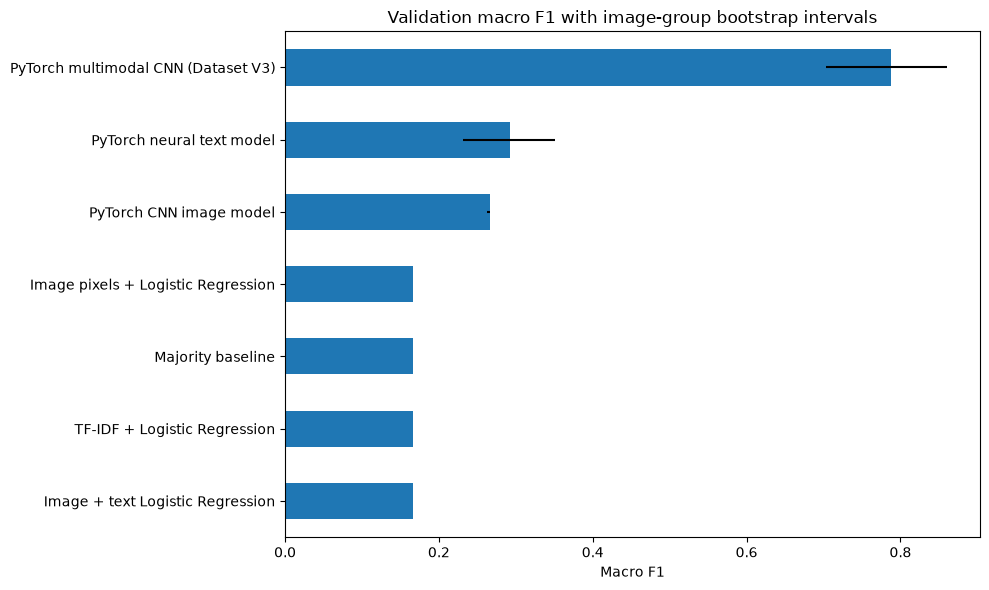

In [7]:
plot_table = model_comparison.sort_values("validation_macro_f1")
error_bars = np.vstack([
    plot_table["validation_macro_f1"] - plot_table["macro_f1_ci_low"],
    plot_table["macro_f1_ci_high"] - plot_table["validation_macro_f1"],
])
ax = plot_table.plot(
    x="model",
    y="validation_macro_f1",
    kind="barh",
    xerr=error_bars,
    legend=False,
    figsize=(10, 6),
)
ax.set_title("Validation macro F1 with image-group bootstrap intervals")
ax.set_xlabel("Macro F1")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 6. Main-model behaviour

The selected development model is `torch_multimodal_dataset_v3`. Its validation metrics are computed from the 480 saved relation predictions, while uncertainty uses 80 independent image groups. The saved result is **377/480 correct relation rows**.

The text-category helper head reaches perfect validation category accuracy, which is expected because the descriptions explicitly name a part. This does not solve the relation task by itself: text category is evenly distributed across relation labels, and both the TF-IDF baseline and neural text model remain at chance relation accuracy.

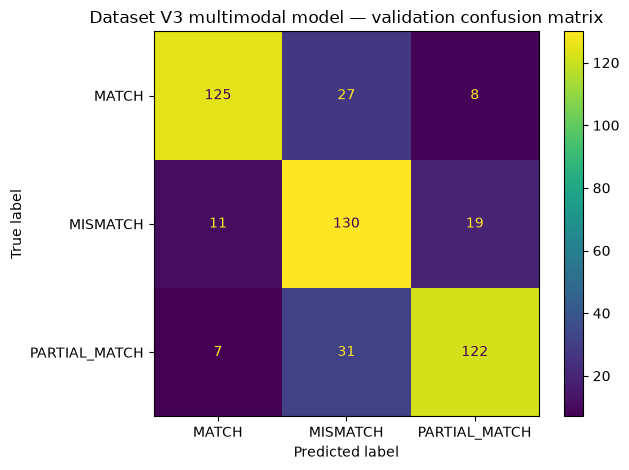

,precision,recall,f1-score,support
MATCH,0.874126,0.781250,0.825083,160.000000
MISMATCH,0.691489,0.812500,0.747126,160.000000
PARTIAL_MATCH,0.818792,0.762500,0.789644,160.000000
accuracy,0.785417,0.785417,0.785417,0.785417
macro avg,0.794802,0.785417,0.787284,480.000000
weighted avg,0.794802,0.785417,0.787284,480.000000


In [8]:
labels = ["MATCH", "MISMATCH", "PARTIAL_MATCH"]
cm = confusion_matrix(
    main_predictions["true_label"],
    main_predictions["predicted_label"],
    labels=labels,
)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(values_format="d")
plt.title("Dataset V3 multimodal model — validation confusion matrix")
plt.tight_layout()
plt.show()

report = pd.DataFrame(
    classification_report(
        main_predictions["true_label"],
        main_predictions["predicted_label"],
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
).T
display(report)

,part_category,samples,independent_images,correct,accuracy,macro_f1
0,alternator,60,10,52,0.866667,0.864829
1,brake_disc,60,10,38,0.633333,0.642593
2,brake_pad,60,10,53,0.883333,0.883960
3,coil_spring,60,10,49,0.816667,0.820842
4,headlight,60,10,37,0.616667,0.628381
5,oil_filter,60,10,34,0.566667,0.562745
6,starter,60,10,58,0.966667,0.966196
7,taillight,60,10,56,0.933333,0.933250


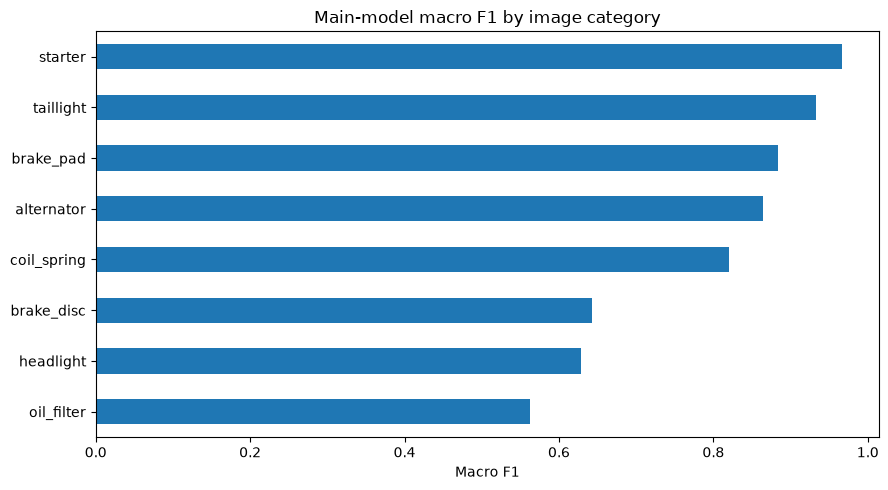

In [9]:
display(per_category)
ax = per_category.sort_values("macro_f1").plot(
    x="part_category",
    y="macro_f1",
    kind="barh",
    legend=False,
    figsize=(9, 5),
)
ax.set_title("Main-model macro F1 by image category")
ax.set_xlabel("Macro F1")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [10]:
errors = main_predictions.loc[
    ~main_predictions["is_correct"],
    [
        "part_category", "text_category", "description",
        "true_label", "predicted_label", "image_path"
    ],
].copy()
error_pairs = (
    errors.groupby(["true_label", "predicted_label"])
    .size()
    .rename("errors")
    .reset_index()
    .sort_values("errors", ascending=False)
)

display(error_pairs)
display(errors.head(15))
print(f"Errors: {len(errors)} of {len(main_predictions)} validation relation rows")

,true_label,predicted_label,errors
5,PARTIAL_MATCH,MISMATCH,31
0,MATCH,MISMATCH,27
3,MISMATCH,PARTIAL_MATCH,19
2,MISMATCH,MATCH,11
1,MATCH,PARTIAL_MATCH,8
4,PARTIAL_MATCH,MATCH,7


,part_category,text_category,description,true_label,predicted_label,image_path
12,alternator,alternator,The pictured part is the automotive alternator...,MATCH,PARTIAL_MATCH,data/images/dataset_v3/validation/alternator/a...
15,alternator,alternator,This engine-support and electrical group compo...,MATCH,PARTIAL_MATCH,data/images/dataset_v3/validation/alternator/a...
25,alternator,starter,The pictured part is the automotive starter mo...,PARTIAL_MATCH,MATCH,data/images/dataset_v3/validation/alternator/a...
28,alternator,starter,This engine-support and electrical group compo...,PARTIAL_MATCH,MATCH,data/images/dataset_v3/validation/alternator/a...
42,alternator,alternator,This engine-support and electrical group compo...,MATCH,PARTIAL_MATCH,data/images/dataset_v3/validation/alternator/a...
43,alternator,starter,This engine-support and electrical group compo...,PARTIAL_MATCH,MISMATCH,data/images/dataset_v3/validation/alternator/a...
45,alternator,alternator,The pictured part is the automotive alternator...,MATCH,PARTIAL_MATCH,data/images/dataset_v3/validation/alternator/a...
46,alternator,starter,The pictured part is the automotive starter mo...,PARTIAL_MATCH,MISMATCH,data/images/dataset_v3/validation/alternator/a...
60,brake_disc,brake_disc,The pictured part is the brake disc or rotor; ...,MATCH,MISMATCH,data/images/dataset_v3/validation/brake_disc/b...
61,brake_disc,brake_pad,The pictured part is the automotive brake pad;...,PARTIAL_MATCH,MISMATCH,data/images/dataset_v3/validation/brake_disc/b...


Errors: 103 of 480 validation relation rows


## 7. Training dynamics

The text and image-only neural models stop near chance relation accuracy. The multimodal model needs more epochs because it learns the relation and two helper category tasks together. Early stopping and model selection use validation, so these results are development estimates rather than a final unbiased test result.

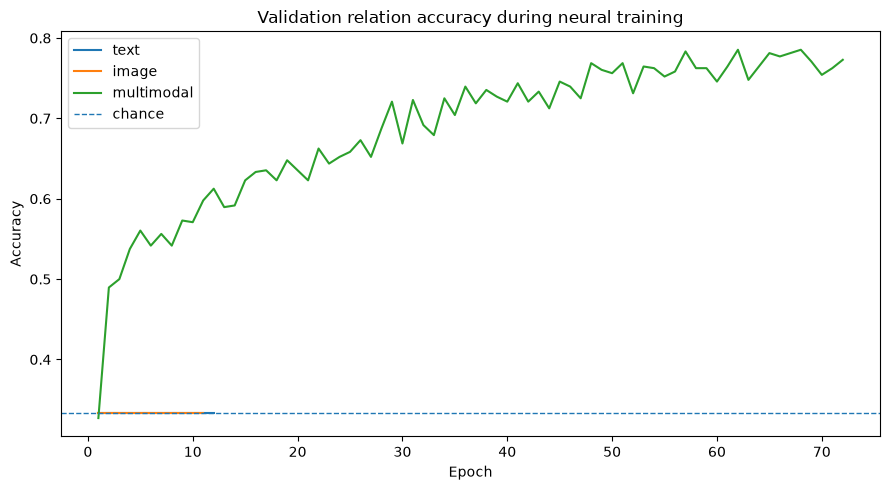

In [11]:
history_files = {
    "text": "torch_text_dataset_v3_training_history.csv",
    "image": "torch_cnn_image_dataset_v3_training_history.csv",
    "multimodal": "torch_multimodal_dataset_v3_training_history.csv",
}
fig, axis = plt.subplots(figsize=(9, 5))
for name, filename in history_files.items():
    history = pd.read_csv(RESULTS / filename)
    axis.plot(history["epoch"], history["val_accuracy"], label=name)
axis.axhline(1 / 3, linestyle="--", linewidth=1, label="chance")
axis.set_title("Validation relation accuracy during neural training")
axis.set_xlabel("Epoch")
axis.set_ylabel("Accuracy")
axis.legend()
plt.tight_layout()
plt.show()

## 8. Paired model comparison

The main model is compared with the majority and simple image-plus-text baselines on the same 80 validation images. The Monte Carlo sign-flip test swaps complete image-group differences rather than treating six rows from one image as independent.

A small p-value supports a difference on this validation set, but it does not remove the need for the locked final test or guarantee the same improvement on another dataset.

In [12]:
display(paired)

main_row = model_comparison.set_index("model_slug").loc["torch_multimodal_dataset_v3"]
baseline_row = model_comparison.set_index("model_slug").loc["image_text_logistic_regression"]
pair_row = paired.loc[
    paired["right_model_slug"].eq("image_text_logistic_regression")
].iloc[0]

print(f"Main-model improvement in accuracy: {main_row.validation_accuracy - baseline_row.validation_accuracy:.4f}")
print(f"Independent validation groups: {int(pair_row.independent_groups)}")
print(f"Grouped two-sided p-value: {pair_row.grouped_two_sided_p_value:.8f}")

,left_model_slug,right_model_slug,method,group_column,independent_groups,paired_rows,left_correct_total,right_correct_total,observed_correct_difference,observed_accuracy_difference,left_better_groups,right_better_groups,tied_groups,left_correct_right_wrong_rows,left_wrong_right_correct_rows,row_discordant_predictions,randomization_assignments,randomization_seed,grouped_two_sided_p_value
0,torch_multimodal_dataset_v3,image_text_logistic_regression,monte_carlo_image_group_sign_flip,image_id,80,480,377,160,217,0.452083,63,11,6,252,35,287,100000,42,0.00001
1,torch_multimodal_dataset_v3,majority,monte_carlo_image_group_sign_flip,image_id,80,480,377,160,217,0.452083,63,11,6,252,35,287,100000,42,0.00001


Main-model improvement in accuracy: 0.4521
Independent validation groups: 80
Grouped two-sided p-value: 0.00001000


## 9. Previous research and source context

The project is much smaller than large vision-language systems, but its design is related to work on joint visual and textual representations:

1. Faghri et al., **VSE++: Improving Visual-Semantic Embeddings with Hard Negatives**, BMVC 2018;
2. Li et al., **VisualBERT: A Simple and Performant Baseline for Vision and Language**, 2019;
3. Radford et al., **Learning Transferable Visual Models From Natural Language Supervision**, ICML 2021;
4. He et al., **Deep Residual Learning for Image Recognition**, CVPR 2016.

The experiment does not reproduce those large models. It uses small supervised networks suitable for a course project. Source provenance, curation decisions, and the Apache-2.0 dataset declaration are recorded in `docs/dataset_v3/` and the Dataset V3 manifests.

## 10. Limitations

- Validation was used for early stopping and model selection, so the reported score is not a final unbiased test score.
- The locked test contains only 80 images and remains unopened until the notebook and modelling decisions are fixed.
- The six relation rows from each image are dependent; row-level sample size must not be presented as independent image count.
- Descriptions explicitly name a part. This is supervised relation classification, not open-vocabulary language understanding.
- The curated public images can still contain source-specific patterns, imperfect framing, and category difficulty differences.
- Image-level grouping and duplicate audits reduce measured leakage, but they do not prove knowledge of the original physical object identity behind every public photograph.

In [13]:
main = model_comparison.set_index("model_slug").loc["torch_multimodal_dataset_v3"]
baseline = model_comparison.set_index("model_slug").loc["image_text_logistic_regression"]
pair = paired.loc[paired["right_model_slug"].eq("image_text_logistic_regression")].iloc[0]

conclusion = (
    f"## 11. Conclusion\n\n"
    f"The Dataset V3 multimodal model achieved **{main.validation_accuracy:.4f} validation accuracy** and **{main.validation_macro_f1:.4f} macro F1**, with **{int(main.correct_predictions)}/{int(main.total_predictions)}** correct relation rows. The grouped 95% accuracy interval was **[{main.accuracy_ci_low:.4f}, {main.accuracy_ci_high:.4f}]** across **{int(main.validation_images)} independent validation images**.\n\n"
    f"The simple image-plus-text Logistic Regression baseline achieved **{baseline.validation_accuracy:.4f} accuracy** and **{baseline.validation_macro_f1:.4f} macro F1**. The grouped paired comparison gave **p = {pair.grouped_two_sided_p_value:.8f}** in this development run.\n\n"
    "The result supports the research question on the validation split: combining the two modalities was substantially more effective than the tested unimodal and simple baselines. It remains a development result. The locked test split was not used and is required for the final one-time evaluation after the project is frozen."
)
display(Markdown(conclusion))

## 11. Conclusion

The Dataset V3 multimodal model achieved **0.7854 validation accuracy** and **0.7873 macro F1**, with **377/480** correct relation rows. The grouped 95% accuracy interval was **[0.7083, 0.8625]** across **80 independent validation images**.

The simple image-plus-text Logistic Regression baseline achieved **0.3333 accuracy** and **0.1667 macro F1**. The grouped paired comparison gave **p = 0.00001000** in this development run.

The result supports the research question on the validation split: combining the two modalities was substantially more effective than the tested unimodal and simple baselines. It remains a development result. The locked test split was not used and is required for the final one-time evaluation after the project is frozen.

In [14]:
assert len(train_images) == 480
assert len(validation_images) == 80
assert len(train_relations) == 2880
assert len(validation_relations) == 480
assert len(all_predictions) == 3360
assert len(main_predictions) == 480
assert training_summary["main_correct_predictions"] == 377
assert np.isclose(training_summary["main_validation_accuracy"], 377 / 480)
assert verification["artifact_consistency"]["saved_metrics_match_predictions"] is True
assert verification["artifact_consistency"]["neural_checkpoints_valid"] is True
assert run_info["test_manifest_read"] is False
assert run_info["test_images_read"] is False
assert run_info["test_split_used"] is False
assert run_info["test_evaluation_permitted"] is False
assert run_info["test_evaluation_executed"] is False
print("Notebook integrity checks passed. The locked test split was not read or evaluated.")

Notebook integrity checks passed. The locked test split was not read or evaluated.
